In [1]:
import pandas as pd 
import numpy as np 
from fbsc_functions import * 
from utils import *

In [2]:
data = pd.read_csv("../data/streamlit_sample_data.csv").set_index("sample_name")
data_ = data.fillna(data.min().min())
metadata = pd.read_csv("../data/streamlit_sample_metadata.csv").set_index("sample_name")

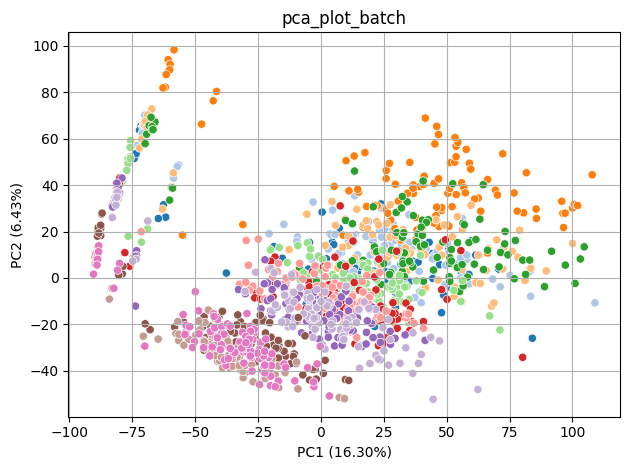

plotting only QC and Biological Samples


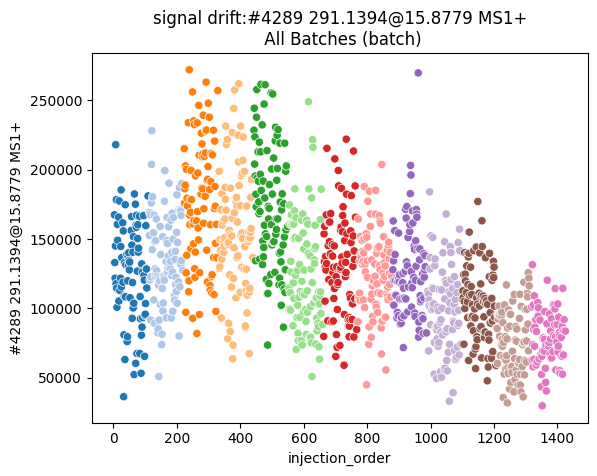

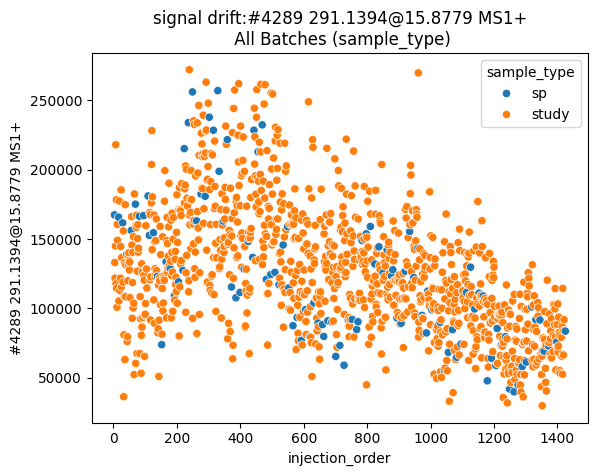

In [3]:
pca_df = pca_plot(data_,metadata,hues=['batch'])
plot_signal_drift(data=data,metadata=metadata,signal_idx=4288,include_all_samples=False,include_all_batches=True)

In [4]:
def remove_qc_outliers(intensity,method='median'):
    if method == 'IQR':
        Q1 = intensity.quantile(0.25)
        Q3 = intensity.quantile(0.75)
        IQR = Q3 - Q1
        upper_bound = Q1 - 2.5 * IQR
        lower_bound = Q3 + 2.5 * IQR
        no_outliers = intensity[(intensity > upper_bound) & (intensity < lower_bound)]
    if method == 'median':
        lower_threshold = intensity.median() * .20
        no_outliers = intensity[intensity >= lower_threshold]
    return no_outliers

In [5]:
# QC-RFSC by Hemi Luan requires first and last sample be QC samples 
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_score
def rfr_function(qc_intensity,bio_intensity,qc_injection_order,bio_injection_order,cv=False):
    
    if qc_intensity.isna().sum() > 5:
        return pd.concat([qc_intensity,bio_intensity],axis=0)
    else: 
        
        qc_no_outliers = remove_qc_outliers(intensity=qc_intensity)
        qc_inj_no_outliers = qc_injection_order[qc_no_outliers.index]
        if qc_no_outliers.empty:
            return pd.concat([qc_intensity,bio_intensity],axis=0)
        X = qc_inj_no_outliers.to_numpy().reshape(-1,1)
        y = qc_no_outliers.to_numpy().ravel()
        if cv:
            rfr = RandomForestRegressor()
            params = {'max_depth':[3,5,10,None],'min_samples_leaf':[1,3,5,10],'max_features':[1,'sqrt','log2'],"n_estimators":[500]}
            cv = GridSearchCV(rfr,params,n_jobs=1,scoring='neg_root_mean_squared_error',cv=LeaveOneOut())
            cv.fit(X,y)
            model = cv.best_estimator_
        else:
            model = RandomForestRegressor(n_estimators=500,max_depth=None,min_samples_leaf=3,random_state=0)
            model.fit(X,y) 
        fitted_values = pd.Series(model.predict(qc_injection_order.to_numpy().reshape(-1,1)),index=qc_intensity.index,name=qc_intensity.name)
        predicted_values = pd.Series(model.predict(bio_injection_order.to_numpy().reshape(-1,1)),index=bio_intensity.index,name=bio_intensity.name)
        adjusted_qc = (qc_intensity / fitted_values) * qc_intensity.median()
        adjusted_bio = (bio_intensity / predicted_values) * qc_intensity.median()
    return pd.concat([adjusted_qc,adjusted_bio],axis=0)

In [6]:
idx = 4288
QC = data.iloc[data.index.str.contains("_SP_"),idx]
Sample = data.iloc[~data.index.str.contains("_SP_"),idx]
QC_injection_order = metadata.loc[QC.index,'injection_order']
Sample_injection_order = metadata.loc[~metadata.index.isin(QC.index),'injection_order']

In [7]:
results = rfr_function(QC,Sample,QC_injection_order,Sample_injection_order)

In [8]:
results = pd.DataFrame(results)
results['injection_order'] = metadata.loc[results.index,"injection_order"]

In [9]:
results = results.sort_values(by='injection_order')

<Axes: xlabel='injection_order', ylabel='#4289 291.1394@15.8779 MS1+'>

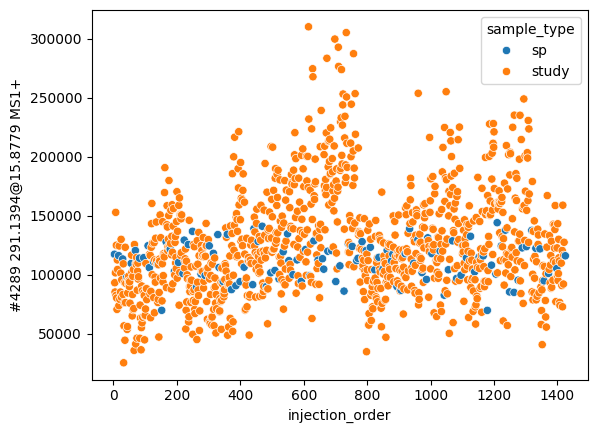

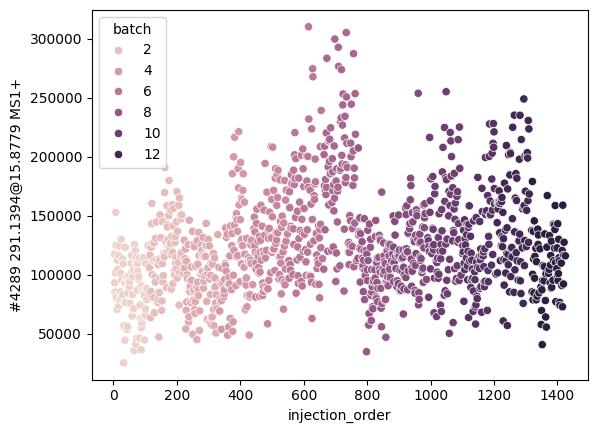

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
results['sample_type'] = metadata['sample_type']
results['batch'] = metadata['batch']
temp = results[(results["sample_type"] == 'sp' )| (results['sample_type'] == 'study')]
sns.scatterplot(temp,x='injection_order',y=temp.columns[0],hue='sample_type')
plt.figure()
sns.scatterplot(temp,x='injection_order',y=temp.columns[0],hue='batch')

In [11]:
from st_processor import FBSC

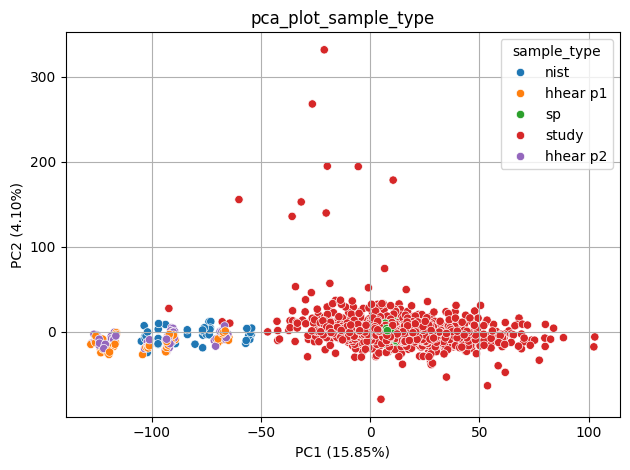

,PC1,PC2,sample_type
sample_name,,,
AOU_NIST_001,-96.966229,3.210831,nist
AOU_HHEAR_P1_001,-116.092187,-0.654573,hhear p1
AOU_SP_001,9.782742,-4.018428,sp
AOU_S_0001,6.053876,13.514186,study
AOU_S_0002,39.698602,-11.245316,study
...,...,...,...
AOU_S_01039,-17.852372,-0.724758,study
AOU_S_01040,3.463545,2.449262,study
AOU_NIST_039,-56.410019,4.016788,nist


In [47]:
test = FBSC(data=pd.read_csv('/Users/jaileru/GitHub/batch-effects-dashboard/data/streamlit_sample_data.csv'),
            metadata=pd.read_csv('/Users/jaileru/GitHub/batch-effects-dashboard/data/streamlit_sample_metadata.csv'),demo=False,method='QC-RFSC')
pca_plot(test.BH1(test.data.fillna(test.data.min().min())),test.metadata)

In [17]:
corrected = test.fbsc_correction(between_batch=True)

Correcting signals...: 100%|█████████████| 10781/10781 [05:08<00:00, 34.94it/s]


In [49]:
x = corrected.fillna(data.min().min())
mask = x < 0
x[mask] = 1

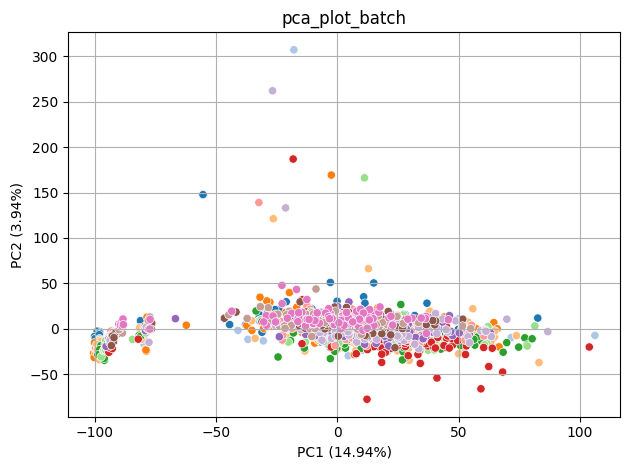

<Axes: xlabel='PC1', ylabel='PC2'>

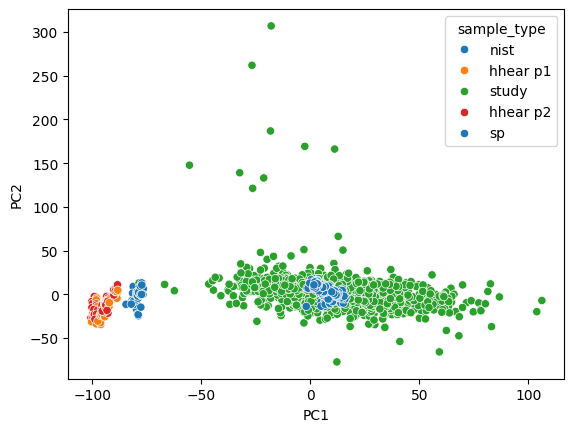

In [56]:
pca_df = pca_plot(x,metadata,hues=['batch'])
pca_df['sample_type'] = metadata['sample_type']
sns.scatterplot(pca_df[~pca_df.index.str.contains("_SP_")],x='PC1',y='PC2',hue='sample_type')
sns.scatterplot(pca_df[pca_df.index.str.contains("_SP_")],x='PC1',y='PC2',hue='sample_type')